In [2]:
'''
Names: Prashant Ram, Muhammad Hassan, Gandhar Tare, Mohamed Burhan
Course: CSC 177
Assignment: 3 - Classification Models On Our Dataset
Professor: Jagannadha Chidella
Details: 
'''

import pandas
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from IPython.display import HTML, display



In [3]:
display(HTML("<h1><strong>Printing Info for our Dataset</strong></h1>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('loan_approval.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
    
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Text', 'Income', 'Credit_Score', 'Rating', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')
We have 20624 rows
We have 8 columns

                                                 Text  Income  Credit_Score  \
0  I want to make home improvements like installi...  197392           389   
1  I need a loan for home renovation, including a...   44561           523   
2  I need funds to buy new furniture and applianc...  190363           729   
3           I need a loan to start a small business.   61853           732   
4  I need a loan to repair my car after an accident.  108236           404   

  Rating  Loan_Amount  DTI_Ratio  Employment_Status  Approval  
0   Poor       111604      22.14                  1         0  
1   Poor        34118      45.44                  1         0  
2   Good       118757      10.22                  0         0  
3   Good        19210      44.13                  1         1  
4   Poor        50797      10.

In [4]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 20624 [original] rows and 8 columns

Original Data:                                                 Text  Income  Credit_Score  \
0  I want to make home improvements like installi...  197392           389   
1  I need a loan for home renovation, including a...   44561           523   
2  I need funds to buy new furniture and applianc...  190363           729   
3           I need a loan to start a small business.   61853           732   
4  I need a loan to repair my car after an accident.  108236           404   

  Rating  Loan_Amount  DTI_Ratio  Employment_Status  Approval  
0   Poor       111604      22.14                  1         0  
1   Poor        34118      45.44                  1         0  
2   Good       118757      10.22                  0         0  
3   Good        19210      44.13                  1         1  
4   Poor        50797      10.24                  1         0  

We have 20624 [Clean] rows and 8 columns

Cleaned data Data:                          

In [5]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [6]:
display(HTML("<h1><strong>Start of Assignment 3</strong></h1>"))

In [7]:
display(HTML("<h1><strong>Classification Model On Our Dataset (Loan Approval Dataset)</strong></h1>"))

In [8]:
'''This block drops all columns which do not help the model learn'''
data = data.drop(['Text'], axis=1)
print(data.columns)


Index(['Income', 'Credit_Score', 'Rating', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')


In [9]:
'''This block converts all the categorical data to numerical data using one-hot encoding.'''

data['Rating'] = data['Rating'].replace({'Poor':0, 'Fair':1 , 'Good':2, 'Very Good':3, 'Excellent':4}).infer_objects(copy=False)
print(data.head())

   Income  Credit_Score  Rating  Loan_Amount  DTI_Ratio  Employment_Status  \
0  197392           389       0       111604      22.14                  1   
1   44561           523       0        34118      45.44                  1   
2  190363           729       2       118757      10.22                  0   
3   61853           732       2        19210      44.13                  1   
4  108236           404       0        50797      10.24                  1   

   Approval  
0         0  
1         0  
2         0  
3         1  
4         0  


C:\Users\rampr\AppData\Local\Temp\ipykernel_4676\4278366314.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Rating'] = data['Rating'].replace({'Poor':0, 'Fair':1 , 'Good':2, 'Very Good':3, 'Excellent':4}).infer_objects(copy=False)


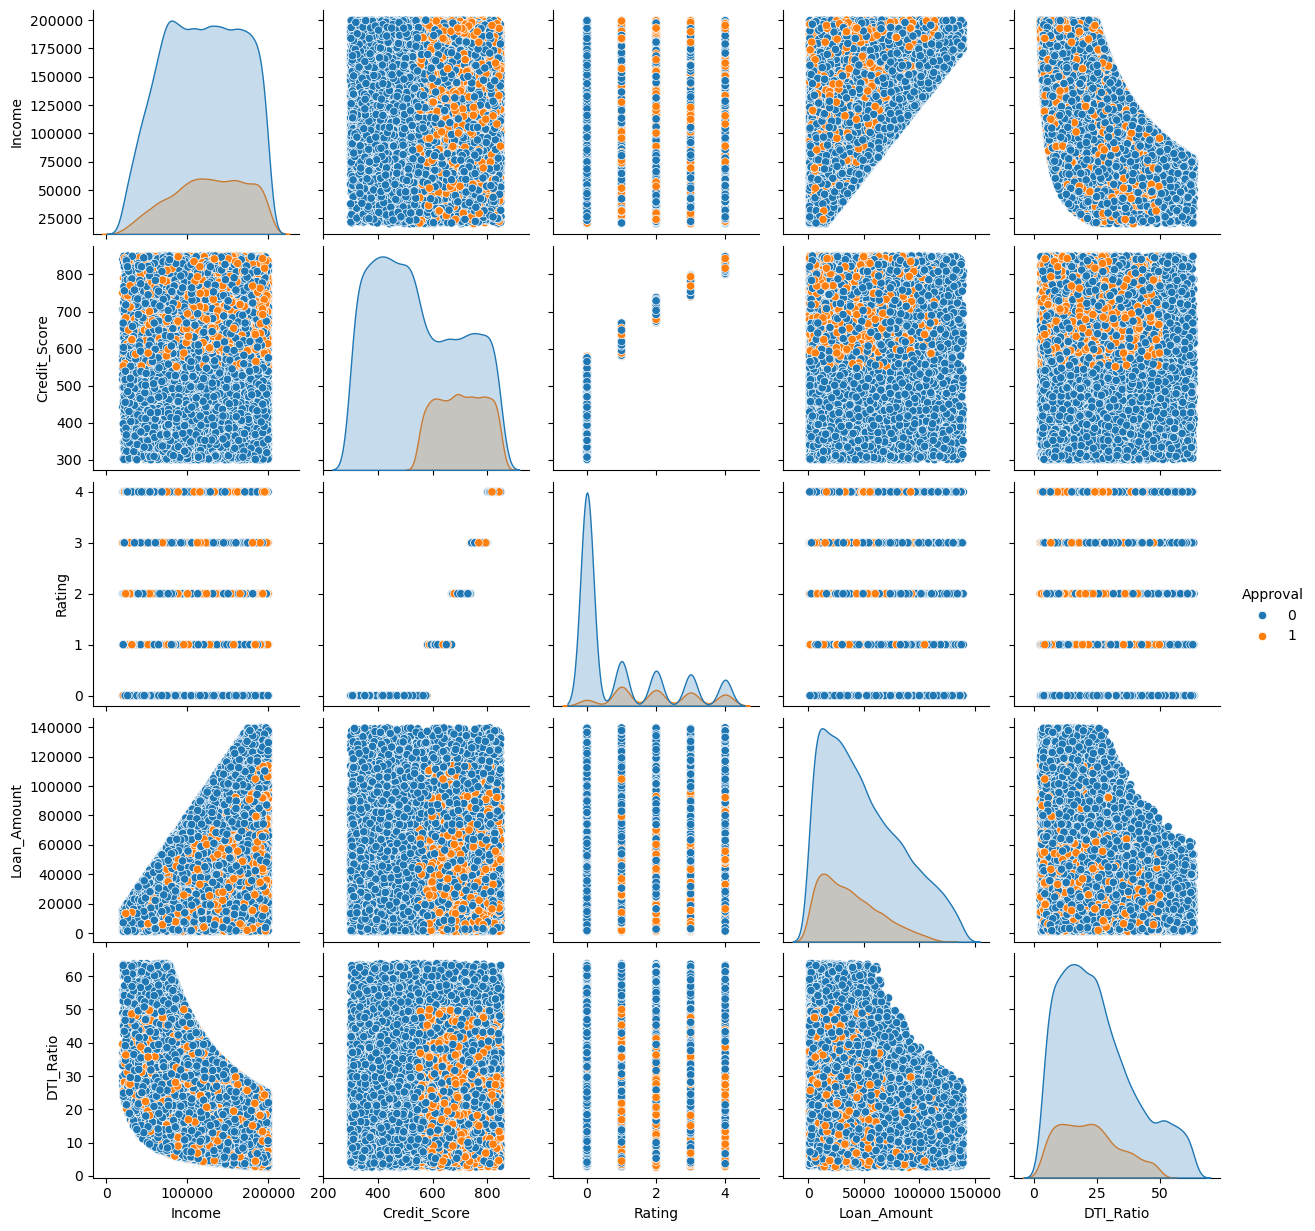

In [10]:
'''We want to look at the relationship between Income, Credit_Score, Rating, Loan_Amount, DTI_Ratio with respect to Approval'''
seaborn.pairplot(data[['Income', 'Credit_Score', 'Rating', 'Loan_Amount', 'DTI_Ratio',  'Approval']], hue='Approval', diag_kind='kde')

In [11]:
'''Lets get our Predictor and Target features'''
x = data.drop(['Approval'], axis=1)
y = data['Approval']

first_k_rows = data.iloc[:20624]
test_y = first_k_rows['Approval']
test_x = first_k_rows.drop(['Approval'], axis=1)

Naive Bayes Accuracy achieved is: 0.8089119472459271


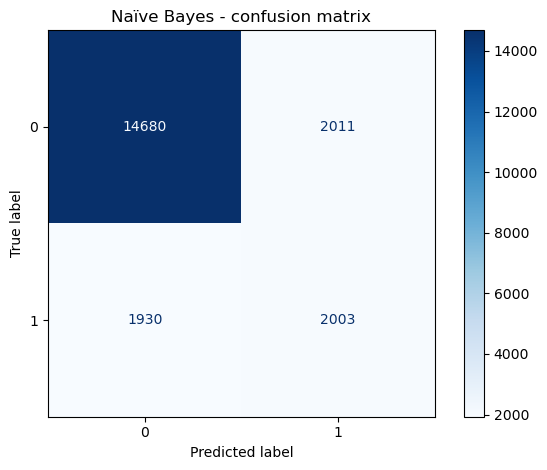

In [12]:
'''
1. We attempt to create the Naive Baynes model
'''

from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB as naive_bayes

accuracy_of_models = []

classification_naive_bayes = naive_bayes()
classification_naive_bayes.fit(x, y)
y_pred_naive_bayes = classification_naive_bayes.predict(test_x)
accuracy_of_models.append(f'Naive Bayes Accuracy achieved is: {accuracy_score(test_y, y_pred_naive_bayes)}')
print(f'Naive Bayes Accuracy achieved is: {accuracy_score(test_y, y_pred_naive_bayes)}')

ConfusionMatrixDisplay.from_predictions(
    test_y,                    
    y_pred_naive_bayes,        
    cmap="Blues"               
)
plt.title("Naïve Bayes - confusion matrix")
plt.tight_layout()
plt.show()


---Trying odd values of k from 1 to 21---
KNN Accuracy achieved with k=1 is: 1.0
KNN Accuracy achieved with k=3 is: 0.8629266873545384
KNN Accuracy achieved with k=5 is: 0.8357738557020946
KNN Accuracy achieved with k=7 is: 0.82316718386346
KNN Accuracy achieved with k=9 is: 0.8174941815360744
KNN Accuracy achieved with k=11 is: 0.8144394879751745
KNN Accuracy achieved with k=13 is: 0.8122090768037238
KNN Accuracy achieved with k=15 is: 0.8108029480217223
KNN Accuracy achieved with k=17 is: 0.8104635376260667
KNN Accuracy achieved with k=19 is: 0.8097362296353763
KNN Accuracy achieved with k=21 is: 0.8091543832428238


---Trying even values of k from 2 to 2---
KNN Accuracy achieved with k=2 is: 0.8613266097750194
KNN Accuracy achieved with k=4 is: 0.8353374709076804
KNN Accuracy achieved with k=6 is: 0.8225368502715283
KNN Accuracy achieved with k=8 is: 0.817300232738557
KNN Accuracy achieved with k=10 is: 0.8140515903801396
KNN Accuracy achieved with k=12 is: 0.8120151280062063
KNN Ac

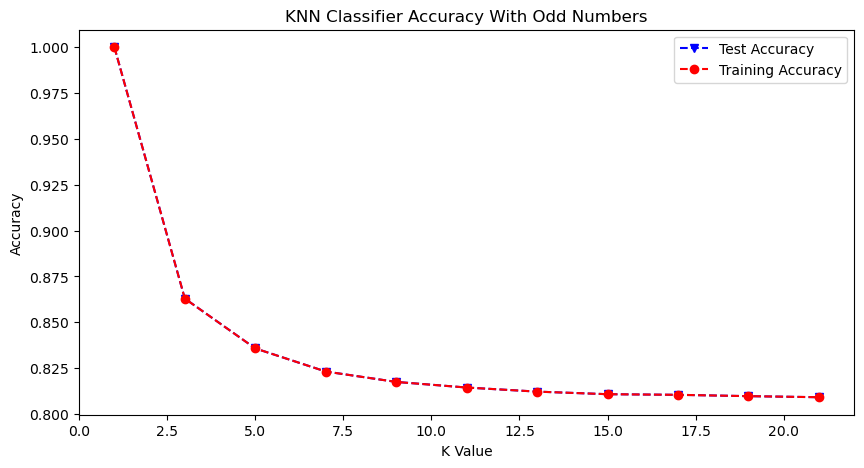

In [13]:
'''
2. We attempt to create the KNN model
'''
from sklearn.neighbors import KNeighborsClassifier as neighbor

odd_neighbors = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
even_neighbors = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
test_accuracy = []
training_accuracy = []

# we try to use odd values of k from 1 to 21
print('---Trying odd values of k from 1 to 21---')
for i in range(1, 22, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(test_x)
    y_pred_knn_train = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(test_y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn_train))
    accuracy_of_models.append(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn_train)}')
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn_train)}') 
print('\n')

# we try to use even values of k from 2 to 22
print('---Trying even values of k from 2 to 2---')
for i in range(2, 23, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn))
    accuracy_of_models.append(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn)}')
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn)}')


# Separate accuracies for odd and even neighbors
odd_test_accuracy = test_accuracy[:len(odd_neighbors)]
odd_training_accuracy = training_accuracy[:len(odd_neighbors)]
even_test_accuracy = test_accuracy[len(even_neighbors):]
even_training_accuracy = training_accuracy[len(even_neighbors):]

# Plotting for odd neighbors since it had the best accuracy
plt.figure(figsize=(10, 5))
plt.plot(odd_neighbors, odd_test_accuracy, 'bv--', odd_neighbors, odd_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Odd Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()


SVM Accuracy achieved with C=0.01 is: 0.8037884665115076
SVM Accuracy achieved with C=0.1 is: 0.8037884665115076
SVM Accuracy achieved with C=0.2 is: 0.8037884665115076
SVM Accuracy achieved with C=0.3 is: 0.8037884665115076
SVM Accuracy achieved with C=0.5 is: 0.8037884665115076
SVM Accuracy achieved with C=0.8 is: 0.8037884665115076
SVM Accuracy achieved with C=1 is: 0.8037884665115076
SVM Accuracy achieved with C=5 is: 0.8037884665115076
SVM Accuracy achieved with C=15 is: 0.8037884665115076
SVM Accuracy achieved with C=20 is: 0.8037884665115076
SVM Accuracy achieved with C=25 is: 0.8037884665115076
SVM Accuracy achieved is: 0.8043056633048875


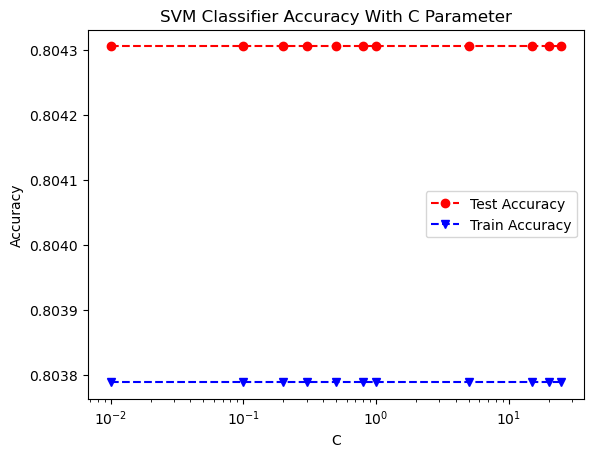

In [14]:
'''
3. We attempt to create the Support Vector Machine (SVM) model
'''
from sklearn.svm import LinearSVC as svc

c_parameter = [0.01, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 5, 15, 20, 25]
svl_test_accuracy = []
svl_training_accuracy = []

# we check to see if the split was already done before we attempt to make the SVM
if 'x_train' not in locals() or 'y_train' not in locals():
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)

for i in c_parameter:
    classification_svm = svc(dual=False, C=i, max_iter=1000, random_state=42)
    classification_svm.fit(x_train, y_train)
    y_pred_svm = classification_svm.predict(x_test)
    y_pred_svm_train = classification_svm.predict(x_train)
    svl_test_accuracy.append(accuracy_score(y_test, y_pred_svm))
    svl_training_accuracy.append(accuracy_score(y_train, y_pred_svm_train))
    accuracy_of_models.append(f'SVM Accuracy achieved with C={i} is: {accuracy_score(y_train, y_pred_svm_train)}')
    print(f'SVM Accuracy achieved with C={i} is: {accuracy_score(y_train, y_pred_svm_train)}')

plt.plot(c_parameter, svl_test_accuracy,'ro--', c_parameter, svl_training_accuracy,'bv--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.title('SVM Classifier Accuracy With C Parameter')
plt.xscale('log')
plt.ylabel('Accuracy')

print(f'SVM Accuracy achieved is: {accuracy_score(y_test, y_pred_svm)}')


Decision Tree Accuracy achieved is: 0.9392940263770365


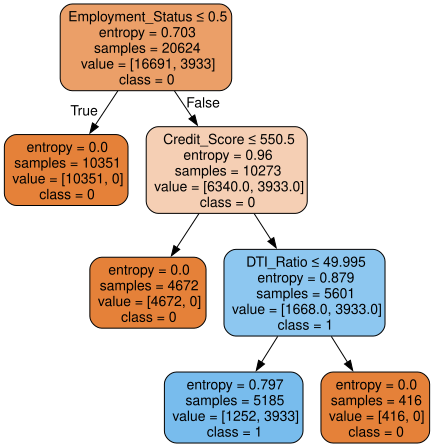

In [15]:
'''
4. We attempt to create the Decision Tree model
'''
decisionTree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
decisionTree = decisionTree.fit(x, y)
y_pred_tree = decisionTree.predict(test_x)

tree_data = tree.export_graphviz(decisionTree, out_file=None,
                                feature_names=x.columns,
                                class_names=['0', '1'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(tree_data)

print(f'Decision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')

# draw the graph
graph

c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=0.01 is: 0.8541020170674942
Logistic Regression Accuracy achieved with C=0.1 is: 0.8536171450737006
Logistic Regression Accuracy achieved with C=0.2 is: 0.8535201706749418


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=0.5 is: 0.8540535298681148
Logistic Regression Accuracy achieved with C=0.8 is: 0.8540535298681148
Logistic Regression Accuracy achieved with C=1 is: 0.8540050426687354
Logistic Regression Accuracy achieved with C=2 is: 0.8539080682699767
Logistic Regression Accuracy achieved with C=5 is: 0.8540050426687354


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=10 is: 0.8540050426687354
Logistic Regression Accuracy achieved with C=20 is: 0.8540535298681148


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0, 0.5, 'Accuracy')

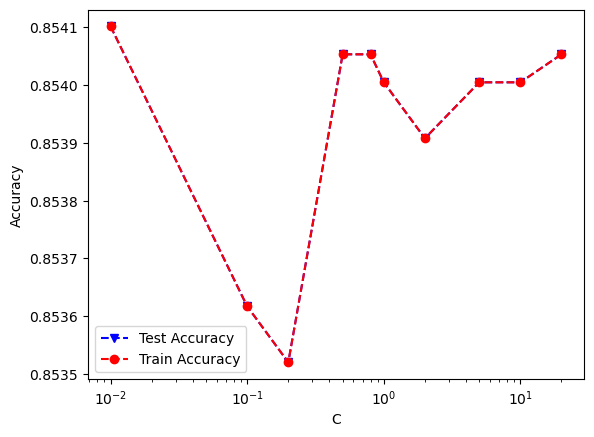

In [16]:
'''
5. We attempt to create the Logistic Regression model
'''
from sklearn.linear_model import LogisticRegression as logistic

c_parama_logistic = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 2, 5, 10, 20]

logistic_test_accuracy = []
logistic_training_accuracy = []

for i in c_parama_logistic:
    classification_logistic = logistic(C=i, random_state=0)
    classification_logistic.fit(x, y)
    y_pred_logistic = classification_logistic.predict(test_x)
    y_pred_logistic_train = classification_logistic.predict(x)
    logistic_test_accuracy.append(accuracy_score(test_y, y_pred_logistic))
    logistic_training_accuracy.append(accuracy_score(y, y_pred_logistic_train))
    accuracy_of_models.append(f'Logistic Regression Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_logistic_train)}')
    print(f'Logistic Regression Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_logistic_train)}')

plt.plot(c_parama_logistic, logistic_test_accuracy,'bv--', c_parama_logistic, logistic_training_accuracy,'ro--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')

In [17]:
print(f'\nDecision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')
accuracy_of_models.append(f'\nDecision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')


Decision Tree Accuracy achieved is: 0.9392940263770365


In [18]:
display(HTML("<h1><strong>Feature Selection And Data Splitting</strong></h1>"))

# Q: A good train and test split is always useful. Duplicates in training and test set should be avoided. Any ML model that trains on a training set which helps explain a lot of variance in the data tend to yield higher accuracy on test set.
# The task of this part is simple: Find a train-test split ratio (for example 80:20) that you think will be best for your ML model to be trained and tested on.


In [19]:
'''Since we will be dealing with Decision Tree Classifier, k-Nearest Neighbor, we will create a pipeline object to ensure reusuability of the code since 
preprocessing and training for each model will be an expensive task'''

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
data = pandas.read_csv('loan_approval.csv')
data_types  = data.dtypes
print(data_types)

Text                  object
Income                 int64
Credit_Score           int64
Rating                object
Loan_Amount            int64
DTI_Ratio            float64
Employment_Status      int64
Approval               int64
dtype: object


In [20]:
'''                           FEATURE SELECTION
We found that #Geography and #Gender are categorical features. Rest are Numerical
'''

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer as Si
from sklearn.preprocessing import StandardScaler as Stdscaler, OneHotEncoder as OHE
from sklearn.compose import ColumnTransformer

data = data.drop(['Text'], axis=1)

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
numeric_features   = ["Income", "Credit_Score", "Loan_Amount", "DTI_Ratio", 
                      "Employment_Status"]

categorical_features  = ["Rating"]

# build the two pipelines
numeric_pipe = Pipeline([('impute', Si(strategy="median")),('scale', Stdscaler())])
categorical_pipe = Pipeline([('impute', Si(strategy="constant", fill_value=-1)),('one-hot', OHE(handle_unknown='ignore'))])

# combine the two pipelines into a single column transformer
combined_pipeline = ColumnTransformer([('numeric', numeric_pipe, numeric_features),('categorical', categorical_pipe, categorical_features)])

print(data.columns)


Index(['Income', 'Credit_Score', 'Rating', 'Loan_Amount', 'DTI_Ratio',
       'Employment_Status', 'Approval'],
      dtype='object')


In [21]:
'''We create a model for the requirements'''

from sklearn.linear_model import LogisticRegression as logistic
from sklearn.tree import DecisionTreeClassifier as decision_tree
from sklearn.neighbors import KNeighborsClassifier as neighbor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB as naive_bayes

models = {
    'Logistic Regression': Pipeline([('combined_pipeline', combined_pipeline), ('Logistic', logistic())]),
    'Decision Tree': Pipeline([('combined_pipeline', combined_pipeline), ('Decision Tree', decision_tree())]),
    'K-Nearest Neighbor': Pipeline([('combined_pipeline', combined_pipeline), ('K-Nearest Neighbor', neighbor())]),
    'Support Vector Classifier': Pipeline([('combined_pipeline', combined_pipeline), ('SVC', SVC())]),
    'Naive Bayes': Pipeline([('combined_pipeline', combined_pipeline), ('Naive Bayes', naive_bayes())])
}


In [22]:
'''                         DATA SPLITTING
We are going to find the best train split mechanism by trying different split ratios.
'''
test_ratio = [0.5, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
results = []

for items, pipe in models.items():
    for ratio in test_ratio:
        # split the data into training and testing sets
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ratio, random_state=42, stratify=y, shuffle=True)
        # fit the pipeline to the training data
        pipe.fit(x_train, y_train)
        split_score = pipe.score(x_test, y_test)
        # append the split score to results
        results.append((items, ratio, split_score))
        print(f"Model: {items}, Test Ratio: {ratio}, Score: {split_score}")
    print('\n')


Model: Logistic Regression, Test Ratio: 0.5, Score: 0.9435608999224204
Model: Logistic Regression, Test Ratio: 0.1, Score: 0.9432864760058167
Model: Logistic Regression, Test Ratio: 0.15, Score: 0.9444085326438267
Model: Logistic Regression, Test Ratio: 0.2, Score: 0.9427878787878788
Model: Logistic Regression, Test Ratio: 0.25, Score: 0.9429790535298681
Model: Logistic Regression, Test Ratio: 0.3, Score: 0.9442469295410472
Model: Logistic Regression, Test Ratio: 0.35, Score: 0.9432054301149744
Model: Logistic Regression, Test Ratio: 0.4, Score: 0.9454545454545454
Model: Logistic Regression, Test Ratio: 0.45, Score: 0.9435405667492727
Model: Logistic Regression, Test Ratio: 0.5, Score: 0.9435608999224204


Model: Decision Tree, Test Ratio: 0.5, Score: 0.9938906128782001
Model: Decision Tree, Test Ratio: 0.1, Score: 0.9927290353853612
Model: Decision Tree, Test Ratio: 0.15, Score: 0.9948287007110537
Model: Decision Tree, Test Ratio: 0.2, Score: 0.992969696969697
Model: Decision Tree, Te

In [23]:
'''Get the best model and split ratio from above'''
another_data = pandas.DataFrame(results, columns=['Model', 'Test Ratio', 'Score'])
best_split_ratio = another_data.loc[another_data.groupby('Model')['Score'].idxmax()]
print("Best Model and their Split Ratio Results:\n", best_split_ratio)

Best Model and their Split Ratio Results:
                         Model  Test Ratio     Score
15              Decision Tree         0.3  0.995314
21         K-Nearest Neighbor         0.1  0.981580
7         Logistic Regression         0.4  0.945455
40                Naive Bayes         0.5  0.838926
31  Support Vector Classifier         0.1  0.988851


In [24]:
'''Through the test we found out the a ratio of 0.25 worked the best for the split so we will utilize that.'''
from sklearn.metrics import accuracy_score

preprocessed_data = ColumnTransformer(transformers=[('numeric', Stdscaler(), numeric_features),('Categorical', OHE(), categorical_features)])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)
pipeline = Pipeline([('preprocess', preprocessed_data), ('classifier', logistic())])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

accuracy_of_prediction = accuracy_score(y_test, y_pred)
print(f'Accuracy of model split of 0.25 prediction is: {accuracy_of_prediction}')


Accuracy of model split of 0.25 prediction is: 0.9429790535298681


In [25]:
display(HTML("<h1><strong>Accuracy and Analysis With Visuals</strong></h1>"))
display(HTML("<h3><strong>These have already been calculated in the previous steps</strong></h3>"))

for i in accuracy_of_models:
    print(i)

Naive Bayes Accuracy achieved is: 0.8089119472459271
KNN Accuracy achieved with k=1 is: 1.0
KNN Accuracy achieved with k=3 is: 0.8629266873545384
KNN Accuracy achieved with k=5 is: 0.8357738557020946
KNN Accuracy achieved with k=7 is: 0.82316718386346
KNN Accuracy achieved with k=9 is: 0.8174941815360744
KNN Accuracy achieved with k=11 is: 0.8144394879751745
KNN Accuracy achieved with k=13 is: 0.8122090768037238
KNN Accuracy achieved with k=15 is: 0.8108029480217223
KNN Accuracy achieved with k=17 is: 0.8104635376260667
KNN Accuracy achieved with k=19 is: 0.8097362296353763
KNN Accuracy achieved with k=21 is: 0.8091543832428238
KNN Accuracy achieved with k=2 is: 0.8613266097750194
KNN Accuracy achieved with k=4 is: 0.8353374709076804
KNN Accuracy achieved with k=6 is: 0.8225368502715283
KNN Accuracy achieved with k=8 is: 0.817300232738557
KNN Accuracy achieved with k=10 is: 0.8140515903801396
KNN Accuracy achieved with k=12 is: 0.8120151280062063
KNN Accuracy achieved with k=14 is: 0.8

In [29]:
# Highest results of classification models
display(HTML("<h3><strong>Accuracy Table Scores</strong></h3>"))
print('ML Model\t\t|\tAccuracy on Test Set (Provide accuracy in %)')
print('-' * 76)
print('Naive Bayes\t\t|\t', 0.8089 * 100)
print('KNN\t\t\t|\t', 0.863 * 100, ', with k=3, gave the highest accuracy')
print('SVM\t\t\t|\t', 0.8038 * 100)
print('Logistic Regression\t|\t', 0.8541 * 100)
print('Decision Tree\t\t|\t', 0.9393 * 100)

ML Model		|	Accuracy on Test Set (Provide accuracy in %)
----------------------------------------------------------------------------
Naive Bayes		|	 80.89
KNN			|	 86.3 , with k=3, gave the highest accuracy
SVM			|	 80.38
Logistic Regression	|	 85.41
Decision Tree		|	 93.93


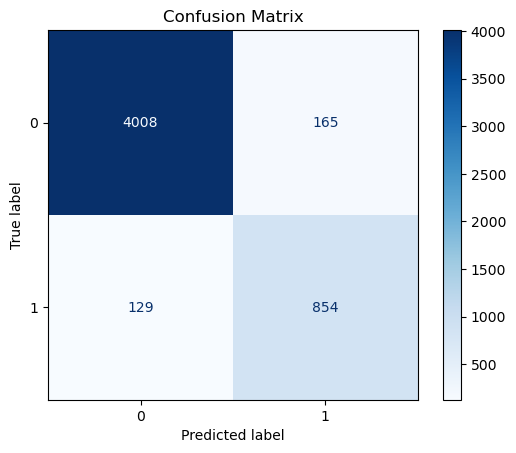

Accuracy on test data is 0.94
F1 score on test data is 0.96
Precision Score on test data is 0.97
Recall score on test data is 0.96
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      4173
           1       0.84      0.87      0.85       983

    accuracy                           0.94      5156
   macro avg       0.90      0.91      0.91      5156
weighted avg       0.94      0.94      0.94      5156

Approval column unique values are: [0 1]


In [27]:
'''Generating a Confusion Matrix to see how well the model is performing'''
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

#generate a confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# we can use either 0 or 1 for "position" the results would be the same.
print(f'Accuracy on test data is %.2f' % accuracy_of_prediction)
print(f'F1 score on test data is %.2f' % f1_score(y_test, y_pred, pos_label=0))
print(f'Precision Score on test data is %.2f' % precision_score(y_test, y_pred, pos_label=0))
print(f'Recall score on test data is %.2f' % recall_score(y_test, y_pred, pos_label=0))
print(classification_report(y_test, y_pred))

# print the unique values in the Exited column just for our sanity check
print('Approval column unique values are:', data.Approval.unique())

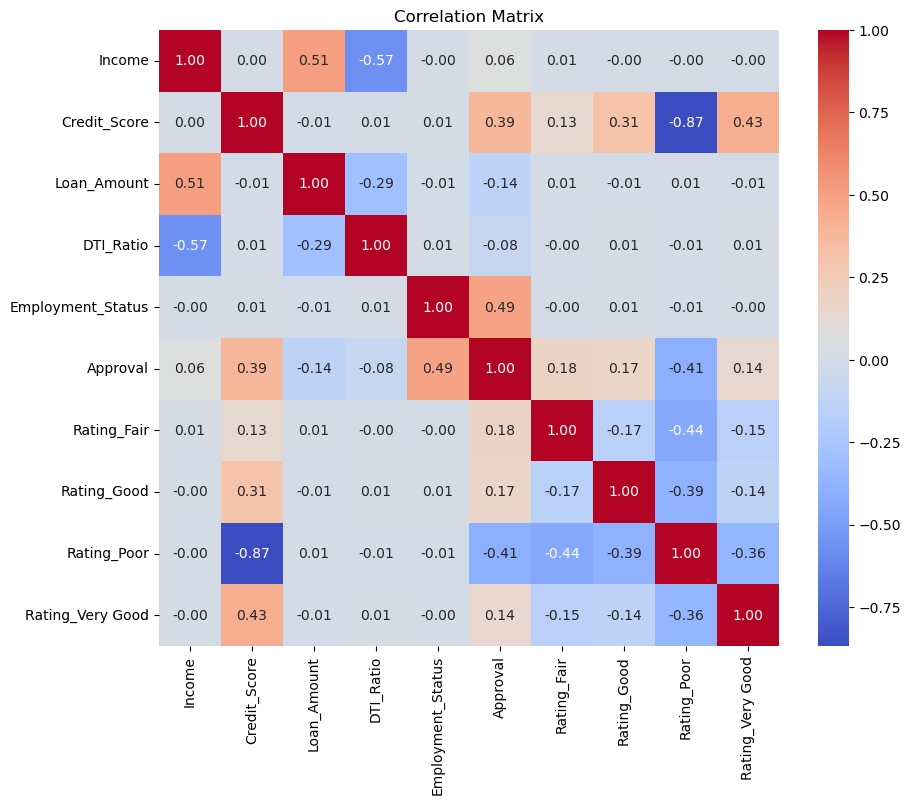

Intepretation of the correlation matrix: The closer the number of a feature row with the feature column to either a 1 or -1, the 
    more correlated they are. The closer the value is to 1, the more the correlation they have in a positive direction and the closer to -1,
    the more correlated they are in a negative direction. A value of 0 means no correlation. For example, 'Income' shows no correlation 
    to 'Credit_Score' as it has a value of 0.00. On the other hand, 'Income' and 'Loan_Amount' have a correlation of 0.51 which means 
    they are positively correlated which makes sense since the loan amount matters alot depends on your income. On the other hand, 
    'Rating_Poor' and 'Credit_Score' have a correlation of -0.87 which means they are negatively correlated which also makes sense since 
    the lower the rating you have, the lower the credit score.


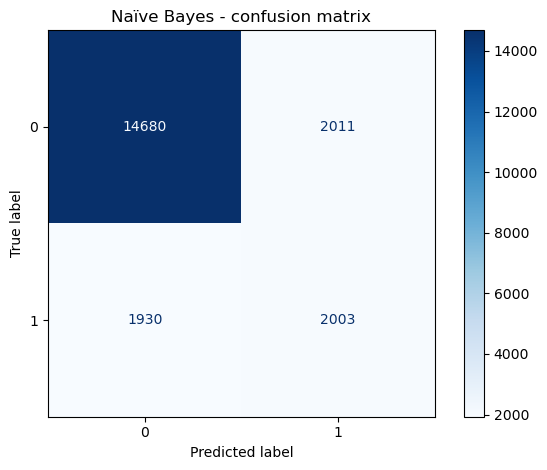

Intepretation of the Naive Baynes Graph: The model was able to predict 14680 'True Negatives' and 2003 'True Positives' correctly.
    It predicted 2011 'False Positives' and 1930 'False Negatives' The overall accuracy of the model was 80.89% which is certainly not too bad
    but it suggests that our data class may have been heavily imbalanced since class 0 was heavier than class 1.


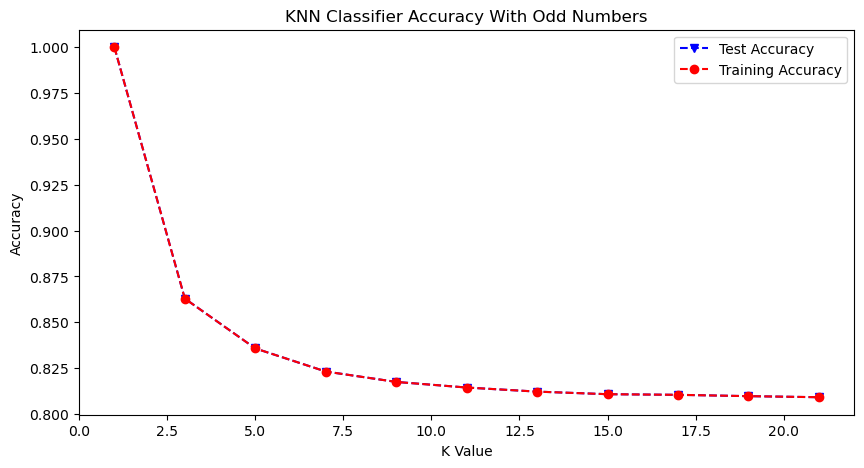

Intepretation of the KNN Graph: The graph shows the different accuracy level for different values of k. The accuracy is highest we saw was 
      set at when k = 3. At k=1, the model was overfitting the data because it had not seen the data yet and at ~k=20, the model was underfitting the 
      data because it had seen all the data. Between k = 3 and 5, we still have a high accuracy but it is still lower than when k = 3. Our test accuracy
      was very well able to predict the data with a 86.3 percent accuracy which is very good.
      


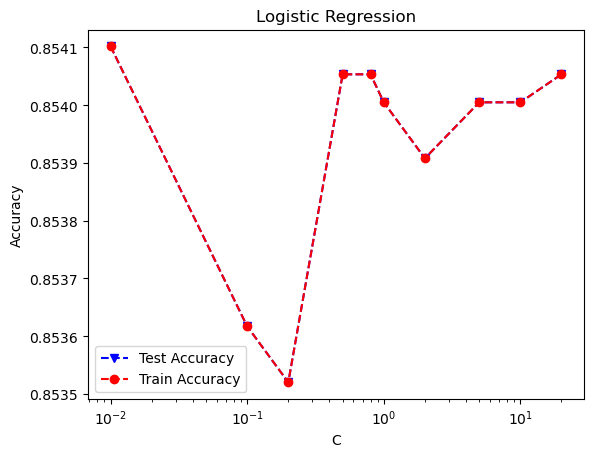

Intepretation of the Logistic Graph: The graph showed that our predicted values were identical which showed low variance which means there was no overfitting.
    Our accruacy range was between 0.8535 to 0.8543 which was a tiny gap and there was very strong regularization for smaller C values. At C = 0.5, we can see a flat
    curve which doesn't mean that the model was overfitting.


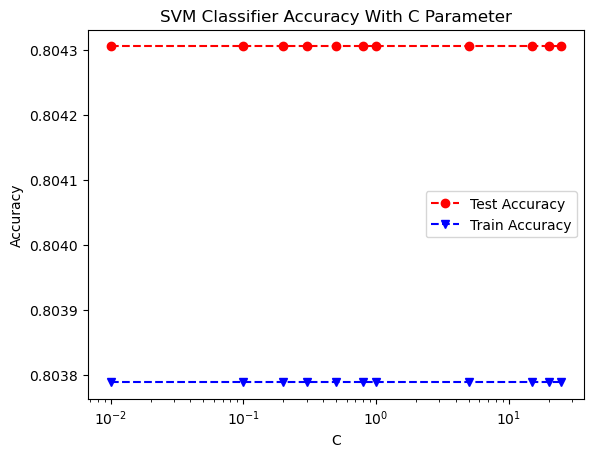

Intepretation of the SVM Graph: We see a line which is flat where the accuracy is about 80.43 percent which means the model has learned everything it can.
    The model is slightly biased because of the gap between the training and the test data. The highest accuracy was about 80.4 percent which was very good.


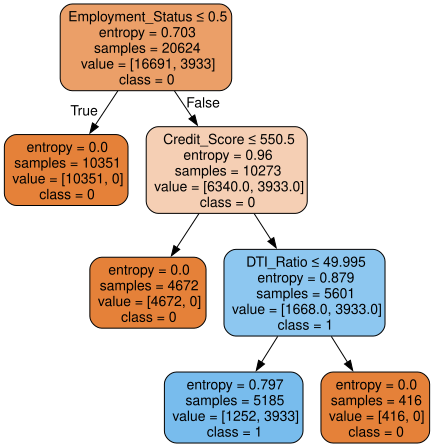

Intepretation of the Decision Tree Graph: The 'Employment_Status' and 'Credit_Score' feature was the most dominant feature in the decision tree model. The DTI_Ratio 
    only matters if the credit score is above 550. We can also deduce that applicants who have an 'Employment_Status' <= 0.5 will be declined and only those with credit score
    of greater than 550 and a DTI ratio of <= 0.5 will be accepted.


In [ ]:
display(HTML("<h3><strong>Overall Correlation Graph for all the Features</strong></h3>"))
coorelation = pandas.get_dummies(data, drop_first=True).corr()
plt.figure(figsize=(10, 8))
seaborn.heatmap(coorelation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print('''Intepretation of the correlation matrix: The closer the number of a feature row with the feature column to either a 1 or -1, the 
    more correlated they are. The closer the value is to 1, the more the correlation they have in a positive direction and the closer to -1,
    the more correlated they are in a negative direction. A value of 0 means no correlation. For example, 'Income' shows no correlation 
    to 'Credit_Score' as it has a value of 0.00. On the other hand, 'Income' and 'Loan_Amount' have a correlation of 0.51 which means 
    they are positively correlated which makes sense since the loan amount matters alot depends on your income. On the other hand, 
    'Rating_Poor' and 'Credit_Score' have a correlation of -0.87 which means they are negatively correlated which also makes sense since 
    the lower the rating you have, the lower the credit score.''')

display(HTML("<h3><strong>Graph for Naive Baynes Classification</strong></h3>"))

ConfusionMatrixDisplay.from_predictions(
    test_y,                    
    y_pred_naive_bayes,        
    cmap="Blues"               
)
plt.title("Naïve Bayes - confusion matrix")
plt.tight_layout()
plt.show()

print('''Intepretation of the Naive Baynes Graph: The model was able to predict 14680 'True Negatives' and 2003 'True Positives' correctly.
    It predicted 2011 'False Positives' and 1930 'False Negatives' The overall accuracy of the model was 80.89% which is certainly not too bad
    but it suggests that our data class may have been heavily imbalanced since class 0 was heavier than class 1.''')

display(HTML("<h3><strong>Graph for KNN Classification</strong></h3>"))

# plotting for odd neighbors
plt.figure(figsize=(10, 5))
plt.plot(odd_neighbors, odd_test_accuracy, 'bv--', odd_neighbors, odd_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Odd Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()

print('''Intepretation of the KNN Graph: The graph shows the different accuracy level for different values of k. The accuracy is highest we saw was 
      set at when k = 3. At k=1, the model was overfitting the data because it had not seen the data yet and at ~k=20, the model was underfitting the 
      data because it had seen all the data. Between k = 3 and 5, we still have a high accuracy but it is still lower than when k = 3. Our test accuracy
      was very well able to predict the data with a 86.3 percent accuracy which is very good.
      ''')

display(HTML("<h3><strong>Graph for Logistic Regression Classification</strong></h3>"))
plt.plot(c_parama_logistic, logistic_test_accuracy,'bv--', c_parama_logistic, logistic_training_accuracy,'ro--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.title('Logistic Regression')
plt.ylabel('Accuracy')
plt.show()

print('''Intepretation of the Logistic Graph: The graph showed that our predicted values were identical which showed low variance which means there was no overfitting.
    Our accruacy range was between 0.8535 to 0.8543 which was a tiny gap and there was very strong regularization for smaller C values. At C = 0.5, we can see a flat
    curve which doesn't mean that the model was overfitting.''')

display(HTML("<h3><strong>Graph for the SVM Classification</strong></h3>"))
plt.plot(c_parameter, svl_test_accuracy,'ro--', c_parameter, svl_training_accuracy,'bv--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.title('SVM Classifier Accuracy With C Parameter')
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')
plt.show()

print('''Intepretation of the SVM Graph: We see a line which is flat where the accuracy is about 80.43 percent which means the model has learned everything it can.
    The model is slightly biased because of the gap between the training and the test data. The highest accuracy was about 80.4 percent which was very good.''')

display(HTML("<h3><strong>Graph for the Decision Tree Classification</strong></h3>"))
tree_data = tree.export_graphviz(decisionTree, out_file=None,
                                feature_names=x.columns,
                                class_names=['0', '1'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(tree_data)
display(graph)

print('''Intepretation of the Decision Tree Graph: The 'Employment_Status' and 'Credit_Score' feature was the most dominant feature in the decision tree model. The DTI_Ratio 
    only matters if the credit score is above 550. We can also deduce that applicants who have an 'Employment_Status' <= 0.5 will be declined and only those with credit score
    of greater than 550.5 and a DTI ratio of <= 49.995 will be accepted.''')